In [35]:
# N=2 Spin System Simulation and its violation of Bell's inequality

In [36]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile
from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt

In [37]:
# Defining a Bell State

def create_bell_state():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0,1)
    return qc

## Measurement in an Arbitrary Basis

The expectation value of the spin operator along an arbitrary unit vector $\hat{\mathbf n}$ cannot be obtained directly on a quantum computer, since measurements are performed in the computational ($S_z$) basis. To measure the spin projection along a different direction, the qubit is first rotated so that the desired measurement axis aligns with the $z$-axis, after which a standard computational basis measurement is performed. 

For a measurement direction specified by the spherical angles $(\theta,\phi)$, ${ \hat n = (sinθcosϕ, sinθsinϕ, cosθ)}$ the required basis transformation is ${U^\dagger(\theta,\phi) = R_y(-\theta)R_z(-\phi)}$ followed by a computational basis measurement.

In [38]:
def measure_in_basis(qc, qubit, theta, phi):
    """
    Rotate the measurement basis to the Z-axis (default basis) and then measure the qubit.
    qc : QuantumCircuit
    qubit : int
    theta : polar angle
    phi : azimuthal angle
    """

    qc.rz(-phi, qubit)
    qc.ry(-theta, qubit)

    return qc

In [39]:
# Function to perform measurements in different bases and compute correlations
def measurements(thetaA, phiA, thetaB, phiB):
    qc = create_bell_state()
    
    # Measure qubit 0 in basis defined by (thetaA, phiA)
    qc = measure_in_basis(qc, 0, thetaA, phiA)
        
    # Measure qubit 1 in basis defined by (thetaB, phiB)
    qc = measure_in_basis(qc, 1, thetaB, phiB)
    
    qc.measure_all()
    
    return qc

In [40]:
# Run the simulation and get the results
def run_simulation(thetaA, phiA, thetaB, phiB, shots=1024):
    qc = measurements(thetaA, phiA, thetaB, phiB)
    simulator = AerSimulator()
    transpiled_qc = transpile(qc, simulator)
    result = simulator.run(transpiled_qc, shots=shots).result() 
    counts = result.get_counts()
    return counts

Consider a spin-zero particle decaying into two spin-1/2 particles. Conservation of angular momentum requires the pair to be produced in the singlet state, in which the spins are maximally entangled. After the particles separate, two observers independently choose measurement directions a and b for their spin detectors. The average product of their measurement outcomes defines the correlation function ${P(a,b)}$. Quantum mechanics predicts ${P(a,b)=−a⋅b}$, whereas any local hidden-variable theory must satisfy the CHSH Bell inequality. 

In [41]:
# Definining a Correlation Function
def correlation(thetaA, phiA, thetaB, phiB, shots=1000):

    counts = run_simulation(thetaA, phiA, thetaB, phiB, shots)

    n00 = counts.get('00', 0)
    n01 = counts.get('01', 0)
    n10 = counts.get('10', 0)
    n11 = counts.get('11', 0)

    E = (n00 + n11 - n01 - n10) / shots

    return E

In [42]:
# Fix the detector of one of the qubits (say Alice), and rotate the other (say Bob)

theta = np.linspace(0, 2*np.pi, 100)
correlations = []

for t in theta:
    E = correlation(0, 0, t, 0)
    correlations.append(E)

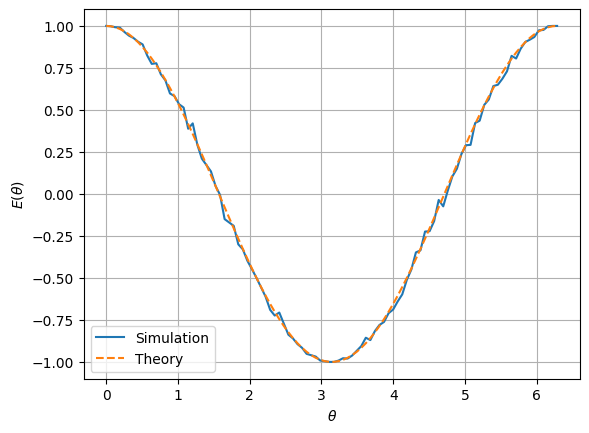

In [ ]:
# Plots

plt.plot(theta, correlations, label="Simulation")

# Theoretically, E(theta) = cos(theta)
plt.plot(theta, np.cos(theta), '--', label="Theory")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$E(\theta)$")
plt.legend()
plt.grid()

plt.show()